# HexMaps — example analysis notebook

This notebook demonstrates how to load a HexMaps `.ecsv` database and make basic plots.

**Requirements:** `hexmaps` installed in your environment (`pip install -e .` from the repo root).

**Before running:** set `ECSV_FILE` in the cell below to point at your output file.

In [1]:
import sys
sys.path.insert(0, "..")   # so hexmaps_analysis.py is found when notebook is in analysis/

import numpy as np
import matplotlib.pyplot as plt

from hexmaps_analysis import HexMapsAnalysis

# -----------------------------------------------------------------
# USER SETTING: path to your .ecsv output file
# -----------------------------------------------------------------
ECSV_FILE = "../output/ngc5194_hexmaps_27p0as_2026_06_30.ecsv"

hm = HexMapsAnalysis(ECSV_FILE)
print(hm)

HexMapsAnalysis(source='ngc5194', n_pts=939, lines=['12CO21', '12CO10'])


## 1 — Inspect the database

The underlying Astropy Table is accessible as `hm.struct`.

In [2]:
print("Source:      ", hm.struct.meta.get("Source"))
print("N sampling points:", len(hm.struct))
print("Lines found: ", hm.lines)
print()
print("All columns:")
for col in hm.struct.colnames:
    print(f"  {col}")

Source:       ngc5194
N sampling points: 939
Lines found:  ['12CO21', '12CO10']

All columns:
  RA
  DEC
  RGAL_AS
  RGAL_KPC
  RGAL_R25
  THETA_RAD
  MAP_SPIRE250
  SPEC_12CO21
  SPEC_12CO10
  SPEC_MASK_12CO21
  SPEC_MASK
  SPEC_VAXIS
  SPEC_VAXIS_SHUFF
  MOM0_12CO21
  EMOM0_12CO21
  TPEAK_12CO21
  RMS_12CO21
  MOM1_12CO21
  EMOM1_12CO21
  MOM2_12CO21
  EMOM2_12CO21
  EW_12CO21
  EEW_12CO21
  SPEC_SHUFF_12CO21
  MOM0_12CO10
  EMOM0_12CO10
  TPEAK_12CO10
  RMS_12CO10
  MOM1_12CO10
  EMOM1_12CO10
  MOM2_12CO10
  EMOM2_12CO10
  EW_12CO10
  EEW_12CO10
  SPEC_SHUFF_12CO10


In [3]:
hm.struct.meta

{'Name': 'HexMaps',
 'Version': '5.0.0',
 'Authors': 'J. den Brok & L. Neumann',
 'Contacts': 'jadenbrok@mpia.de & lukas.neumann@eso.org',
 'Credits': ['M. Jimenez-Donaire', 'E. Rosolowsky', 'A. Leroy', 'I. Beslic'],
 'User': 'Dr. Blocksberg',
 'Comments': 'Example HexMaps run',
 'Date': '2026_06_30',
 'Source': 'ngc5194',
 'config_file': '# =============================================================================\\n# HexMaps config.txt\\n# =============================================================================\\n# Single configuration file for a HexMaps run. Combines what used to be\\n# master_key.txt + data_key.txt + config_key.txt.\\n#\\n# Run with:\\n#   hexmaps --conf config.txt\\n#\\n# Two files are intentionally kept SEPARATE from this one, in a fixed `keys/`\\n# subfolder next to this config.txt, because they change far less often than\\n# everything below:\\n#   keys/target_definitions.txt   — source geometry (RA, Dec, distance, ...)\\n#   keys/hfs_lines.txt         

## 2 — Moment-0 map

Plot the integrated intensity map for the first spectral line.

Plotting MOM0 for: 12CO21


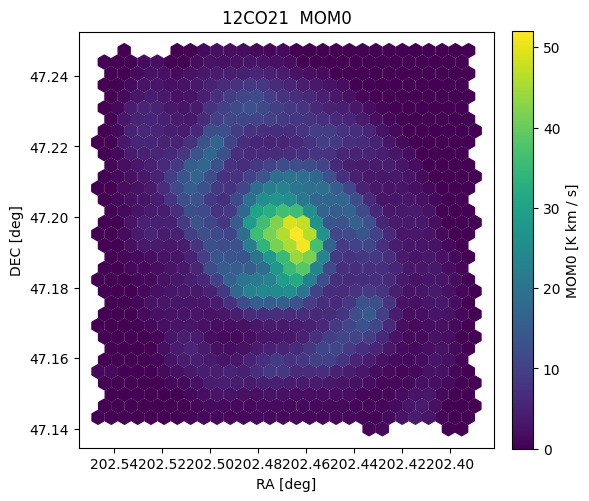

In [4]:
line = hm.lines[0]   # e.g. "12CO21"
print(f"Plotting MOM0 for: {line}")

hm.quickplot_map(line, quantity="MOM0")

### 2a — Same map in offset coordinates

Pass the source centre as an RA/Dec string to switch to arcsecond offsets.

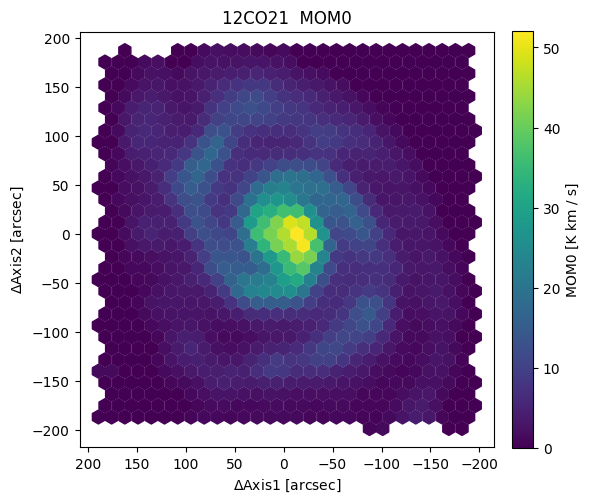

In [5]:
# Adjust centre coordinates to match your source
CENTER = "13:29:52.7 +47:11:43"   # NGC 5194 (M51a)

hm.quickplot_map(line, quantity="MOM0", center=CENTER)

### 2b — Peak brightness map

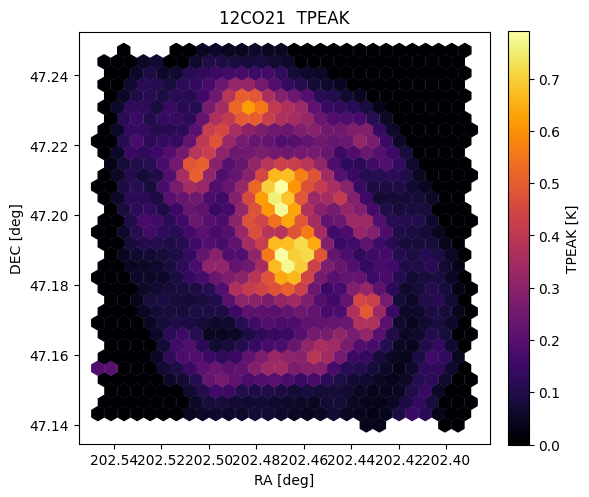

In [6]:
hm.quickplot_map(line, quantity="TPEAK", cmap="inferno")

## 3 — Moment-1 (mean velocity) map

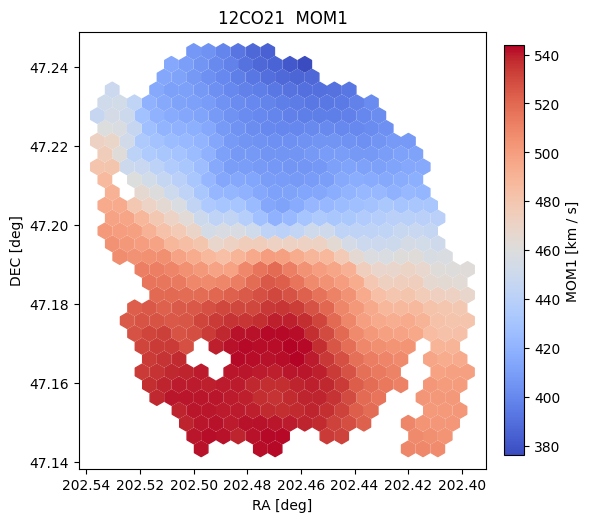

In [7]:
hm.quickplot_map(line, quantity="MOM1", cmap="coolwarm", s=125)

## 4 — Individual spectrum

Plot the spectrum at the sampling point closest to the source centre.
The shaded region shows the integration mask.

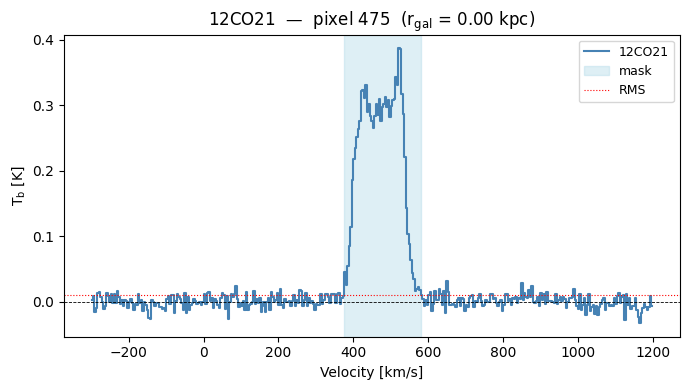

In [8]:
hm.quickplot_spectrum(line, show_mask=True, show_rms=True)

### 4a — Spectrum at a specific pixel index

Brightest pixel index: 474  (rgal = 0.61 kpc)


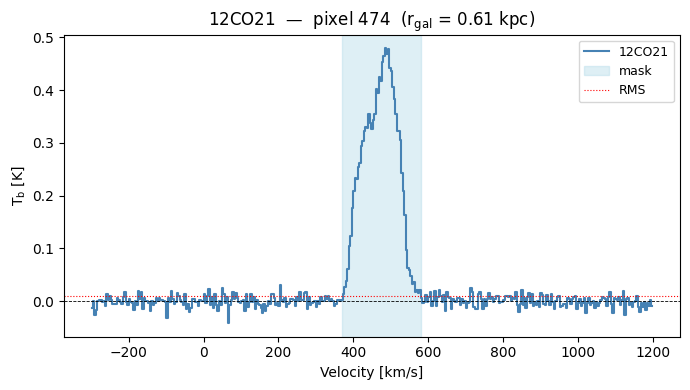

In [9]:
# Pick any index, e.g. a pixel with strong emission
mom0 = hm.get_mom0(line)
bright_idx = int(np.nanargmax(mom0))
print(f"Brightest pixel index: {bright_idx}  (rgal = {hm.rgal[bright_idx]:.2f} kpc)")

hm.quickplot_spectrum(line, idx=bright_idx, show_mask=True, show_rms=True)

## 5 — Shuffled (velocity-shifted) spectrum

The shuffled spectrum has been shifted so the emission is centred at v = 0.

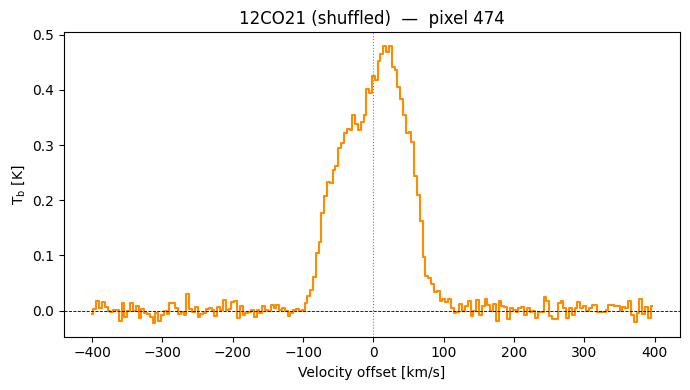

In [10]:
hm.quickplot_shuffled_spectrum(line, idx=bright_idx)

## 6 — Radial profile

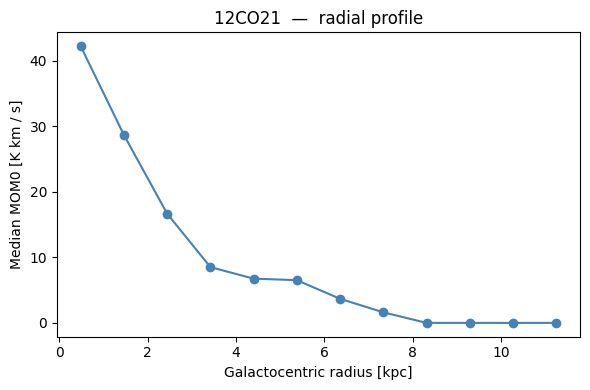

In [11]:
hm.quickplot_radial_profile(line, quantity="MOM0", nbins=12)

## 7 — Multi-panel overview

Combine several plots into one figure.

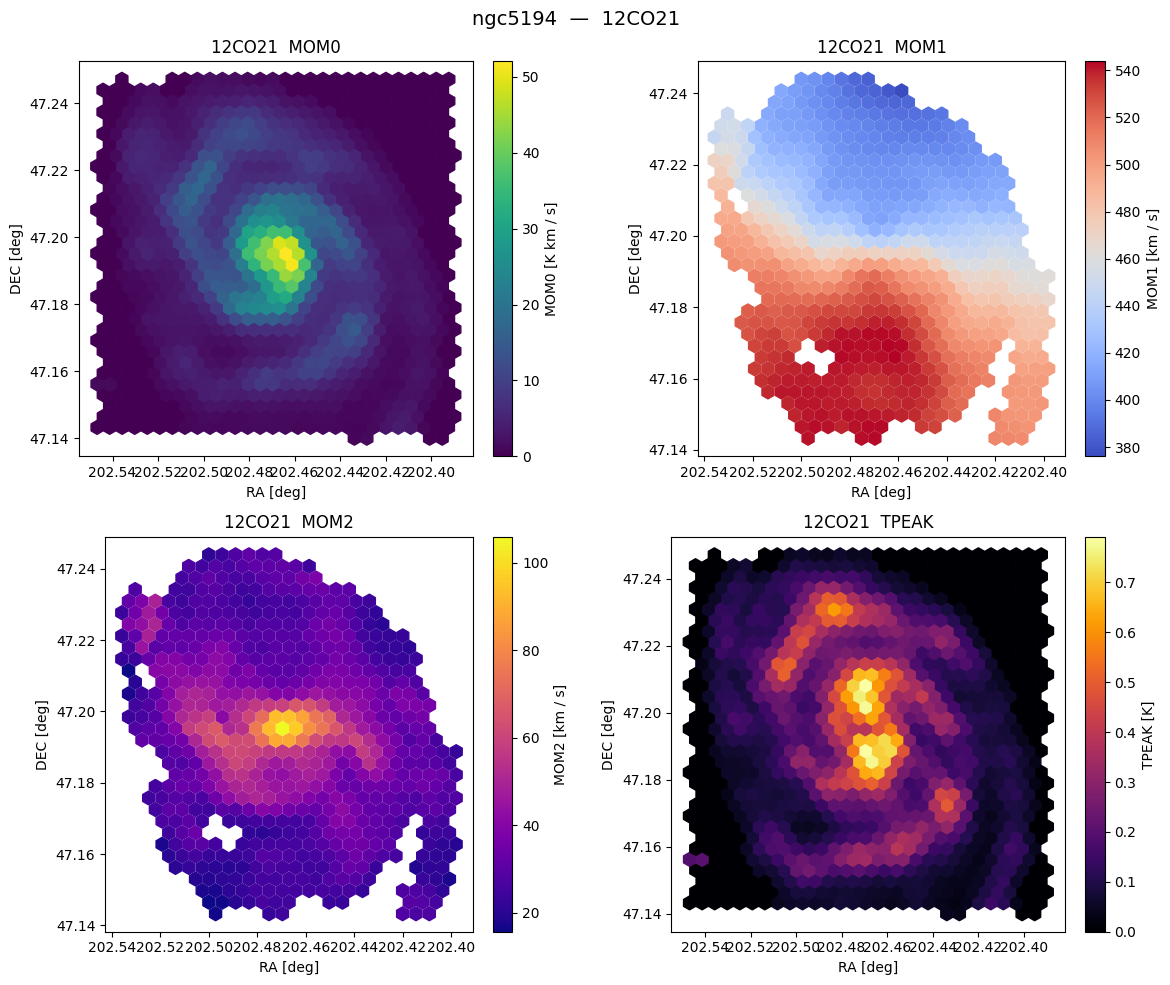

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

hm.quickplot_map(line, quantity="MOM0",  ax=axes[0, 0])
hm.quickplot_map(line, quantity="MOM1",  ax=axes[0, 1], cmap="coolwarm")
hm.quickplot_map(line, quantity="MOM2",  ax=axes[1, 0], cmap="plasma")
hm.quickplot_map(line, quantity="TPEAK", ax=axes[1, 1], cmap="inferno")

fig.suptitle(f"{hm.struct.meta.get('Source', '')}  —  {line}", fontsize=14)
plt.tight_layout()
plt.show()

## 8 — Line ratio (if two lines are available)

Skip this cell if only one line is in the database.

Computing ratio: 12CO21 / 12CO10


/Users/lneumann/work/scripts/HexMaps/analysis/hexmaps_analysis.py:429: RuntimeWarning: invalid value encountered in divide
  det = (i1 / e1 > sn) & (i2 / e2 > sn)
/Users/lneumann/work/scripts/HexMaps/analysis/hexmaps_analysis.py:435: RuntimeWarning: invalid value encountered in divide
  ul = (~det) & (i2 / e2 > sn)
/Users/lneumann/work/scripts/HexMaps/analysis/hexmaps_analysis.py:438: RuntimeWarning: invalid value encountered in divide
  ll = (i1 / e1 > sn) & (~det)


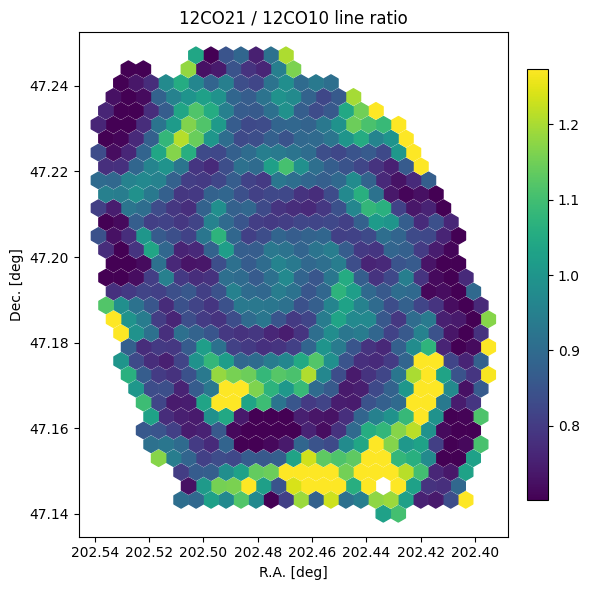

In [13]:
import matplotlib.colors as mcolors
if len(hm.lines) >= 2:
    line1, line2 = hm.lines[0], hm.lines[1]
    print(f"Computing ratio: {line1} / {line2}")

    ratio = hm.get_ratio(line1, line2, sn=5)
    r = ratio["ratio"]

    ra, dec = hm.get_coordinates()
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.scatter(ra, dec, c=r, s=140, marker="h",
                    cmap="viridis",
                    norm=mcolors.Normalize(vmin=np.nanpercentile(r, 5),
                                           vmax=np.nanpercentile(r, 95)))
    ax.invert_xaxis()
    ax.set_xlabel("R.A. [deg]")
    ax.set_ylabel("Dec. [deg]")
    ax.set_title(f"{line1} / {line2} line ratio")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Only one line in database — skipping ratio plot.")

## 9 — Export a 2D-only table (no spectra)

Useful for sharing or downstream analysis when you don't need the full spectra.

In [14]:
tbl_2d = hm.get_2D_database(save=False)
print("2D table columns:")
for col in tbl_2d.colnames:
    print(f"  {col}")

2D table columns:
  RA
  DEC
  RGAL_AS
  RGAL_KPC
  RGAL_R25
  THETA_RAD
  MAP_SPIRE250
  MOM0_12CO21
  EMOM0_12CO21
  TPEAK_12CO21
  RMS_12CO21
  MOM1_12CO21
  EMOM1_12CO21
  MOM2_12CO21
  EMOM2_12CO21
  EW_12CO21
  EEW_12CO21
  MOM0_12CO10
  EMOM0_12CO10
  TPEAK_12CO10
  RMS_12CO10
  MOM1_12CO10
  EMOM1_12CO10
  MOM2_12CO10
  EMOM2_12CO10
  EW_12CO10
  EEW_12CO10


## 10 — Export config file, input headers, and log

Useful for extracting the input information from hexmaps database.

In [15]:
config_txt = hm.get_config(
    #save_to='config_from_ecsv.txt'  # uncomment to save to file
)
print(config_txt)

# =============================================================================
# HexMaps config.txt
# =============================================================================
# Single configuration file for a HexMaps run. Combines what used to be
# master_key.txt + data_key.txt + config_key.txt.
#
# Run with:
#   hexmaps --conf config.txt
#
# Two files are intentionally kept SEPARATE from this one, in a fixed `keys/`
# subfolder next to this config.txt, because they change far less often than
# everything below:
#   keys/target_definitions.txt   — source geometry (RA, Dec, distance, ...)
#   keys/hfs_lines.txt             — hyperfine structure line definitions (optional)
#
# Lines starting with '#' are comments.
# =============================================================================

[meta]
# Your name — stored in the output table metadata
user = Dr. Blocksberg

# Free-form comment stored in the output table metadata
comments = Example HexMaps run

# ---------------------

In [16]:
hm.get_input_header(line)

SIMPLE  =                    T / Written by IDL:  Tue Jul 30 23:25:31 2019      
BITPIX  =                  -32 /  IEEE single precision floating point          
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  123 /                                                
NAXIS2  =                  121 /                                                
NAXIS3  =                  375 /                                                
DATE    = '2019-07-30'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    
CTYPE3  = 'VELO-LSR'           /                                                
CUNIT3  = 'm/s     '                                                            
CRVAL3  =       -297795.518331 /                                                
CRPIX3  =                   

In [17]:
logger = hm.get_log(
     #save_to='log_file.txt'  # uncomment to save to file
)
print(logger)

2026-06-30 13:07:56 [Loading]  [INFO]    Loading config file ...
2026-06-30 13:07:56 [Loading]  [INFO]    Loaded 1 source(s): ['ngc5194']
2026-06-30 13:07:56 [Loading]  [INFO]    Running stages: ['regrid', 'products']
2026-06-30 13:07:56 [Loading]  [INFO]    The 'fits' stage is not included in the current run. To enable FITS output, add 'fits' to your stage list.
2026-06-30 13:07:56 [Loading]  [INFO]    --- Processing source: ngc5194 ---
2026-06-30 13:08:14 [Regrid]   [INFO]    Convolving and sampling data for ngc5194.
2026-06-30 13:08:14 [Regrid]   [INFO]    Overlay file: /Users/lneumann/work/scripts/HexMaps/data/ngc5194_12co21.fits
2026-06-30 13:08:14 [Regrid]   [INFO]    Angular resolution: 27.0 arcsec.
2026-06-30 13:08:14 [Regrid]   [INFO]    Hex grid footprint eroded by 3 px (0.5 beam = 13.5 arcsec); 9224 of 10422 pixels retained.
2026-06-30 13:08:14 [Regrid]   [INFO]    Auto max_rad = 0.096 deg.
2026-06-30 13:08:14 [Regrid]   [INFO]    Hexagonal grid generated: 939 sampling point